In [ ]:
import matplotlib.pyplot as plt
from google.colab import files


In [44]:
import json

with open("individual_param_sweep_withcost.json", "r") as f:
    results = json.load(f)

In [47]:
def get_metric(results, metric, benchmark,l1d_assoc="2", l1i_assoc="2", l2_assoc="1",l1d_size="128kB", l1i_size="128kB",l2_size="1MB", cache_line="64", max_inst="100000000"):
    for config, entry in results[benchmark].items():
        p = entry["params"]

        if (
            p["cache_line"] == cache_line and
            p["l1d_assoc"] == l1d_assoc and
            p["l1d_size"] == l1d_size and
            p["l1i_assoc"] == l1i_assoc and
            p["l1i_size"] == l1i_size and
            p["l2_assoc"] == l2_assoc and
            p["l2_size"] == l2_size
        ):
            return entry[metric]

    return None

[['401.bzip2', 2.2637802066276995, 2.255289467874758, 2.2361405781280546, 2.231741286000795], ['429.mcf', 1.0525985588737579, 1.051924068121026, 1.0493991027383014, 1.0472821317619736], ['456.hmmer', 1.0055767058909342, 1.005578705885874, 1.005576205892199, 1.005576205892199], ['458.sjeng', 5.646470868070107, 5.646579367883487, 5.646431868137187, 5.646325868319506], ['470.lbm', 1.8589304769358022, 1.8589304769358022, 1.8589304769358022, 1.8589304769358022]]


In [56]:
def plot_all_metrics_for_benchmark(var_name, var_values, cpi_values, cost_values, eval_values):
  for i, benchmark in enumerate(benchmarks):
          cpi_values = cpi_data[i][1:]
          cost_values = cost_data[i][1:]
          eval_values = eval_data[i][1:]

          plt.figure()

          plt.plot(var_values, cpi_values, marker='o', label='CPI')
          plt.plot(var_values, cost_values, marker='o', label='Cost')
          plt.plot(var_values, eval_values, marker='o', label='Eval')

          plt.xlabel(var_name)
          plt.ylabel("Value")
          plt.title(f"CPI, Cost, and Eval vs {var_name} for {benchmark}")
          plt.legend()
          plt.grid(True)
          plt.tight_layout()

          filename = f"{var_name.replace(' ', '_')}_all_metrics_{benchmark}.png"
          plt.savefig(filename)
          files.download(filename)
          plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

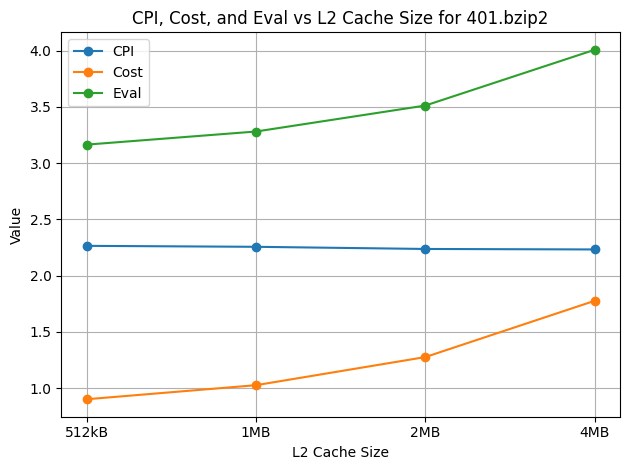

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

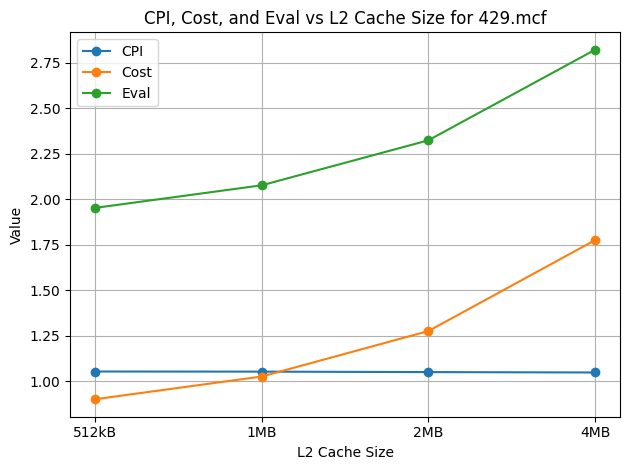

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

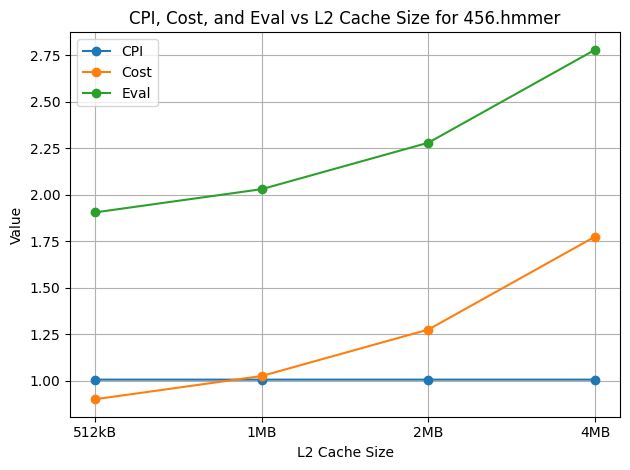

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

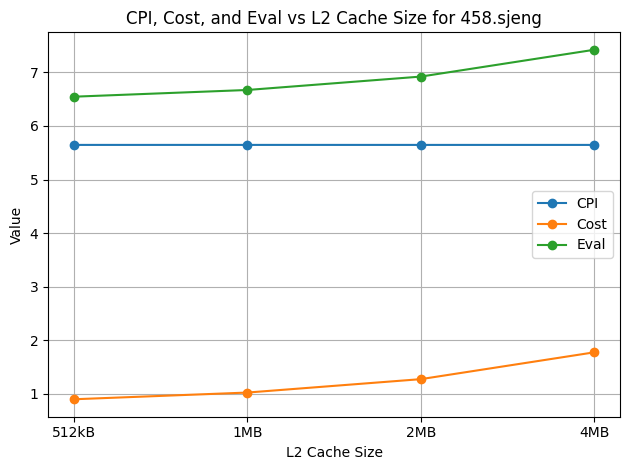

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

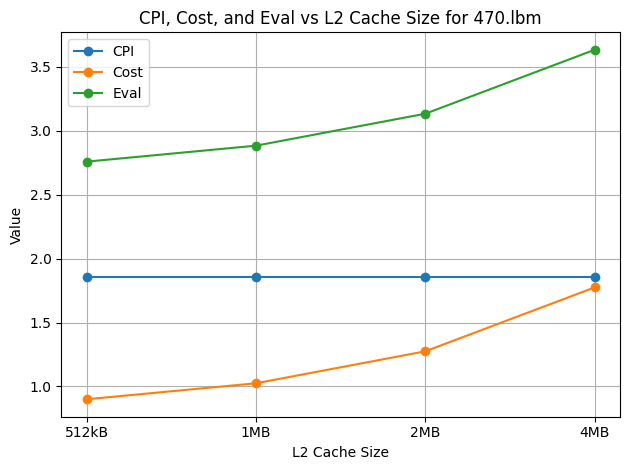

In [57]:
benchmarks = ["401.bzip2", "429.mcf", "456.hmmer", "458.sjeng", "470.lbm"]

cpi_data = []
cost_data = []
eval_data = []
l2_sizes = ['512kB', '1MB', '2MB', '4MB']
for benchmark in benchmarks:
    cpi_row = [benchmark]
    cost_row = [benchmark]
    eval_row = [benchmark]

    for l2_size in l2_sizes:
      cpi_row.append(get_metric(results, "CPI", benchmark, l2_size=l2_size))
      cost_row.append(get_metric(results, "cost", benchmark, l2_size=l2_size))
      eval_row.append(get_metric(results, "eval", benchmark, l2_size=l2_size))

    cpi_data.append(cpi_row)
    cost_data.append(cost_row)
    eval_data.append(eval_row)


plot_all_metrics_for_benchmark("L2 Cache Size", l2_sizes, cpi_data, cost_data, eval_data)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

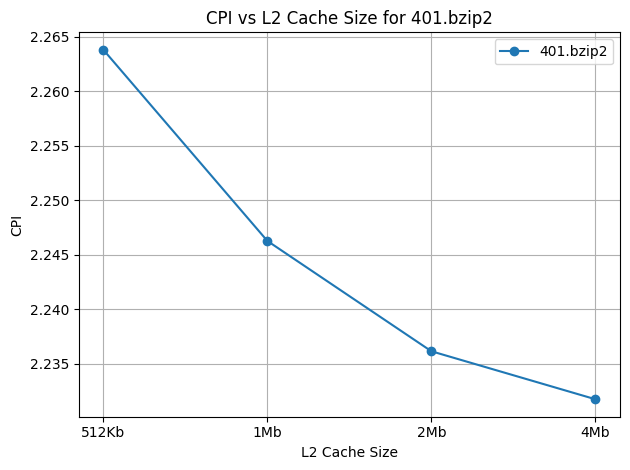

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

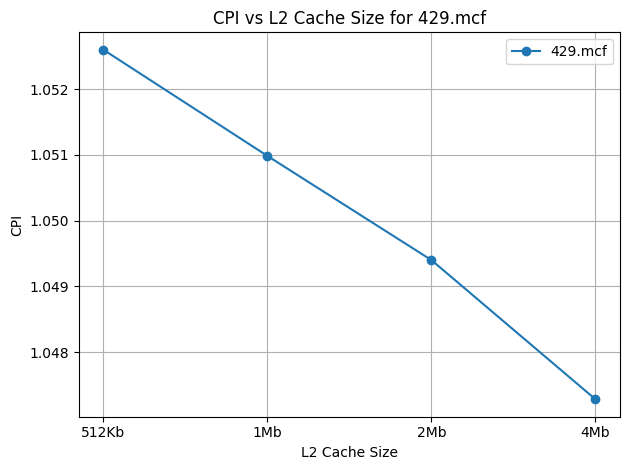

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

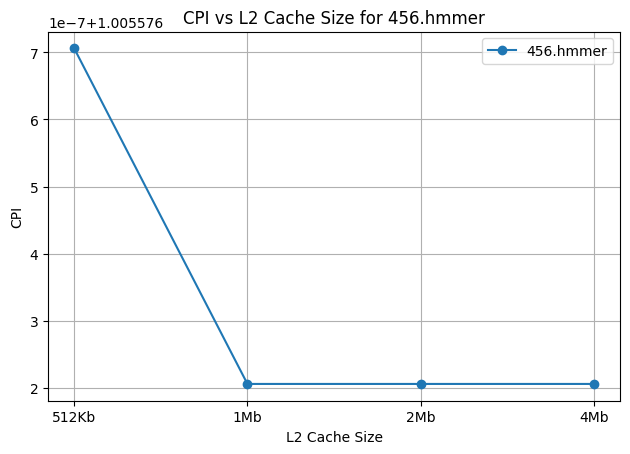

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

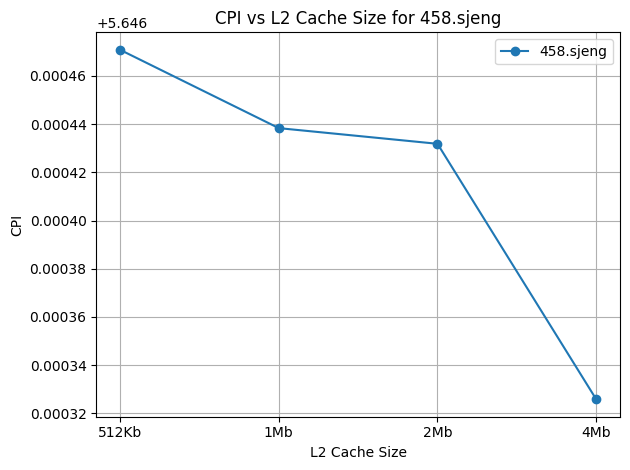

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

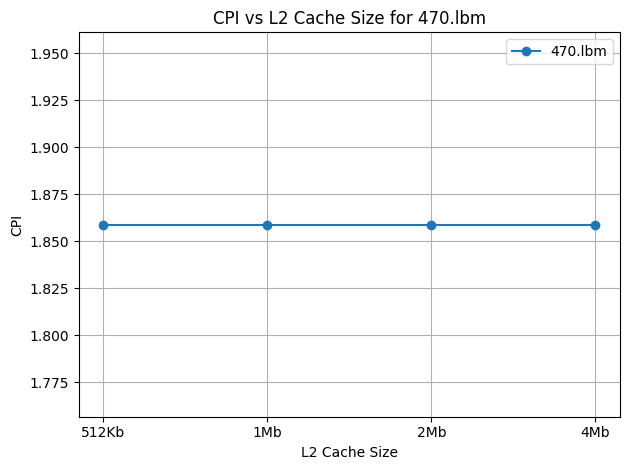

In [38]:
import matplotlib.pyplot as plt
from google.colab import files

cache_sizes = ['512Kb', '1Mb', '2Mb', '4Mb']

data = [
    ["401.bzip2", 2.2637802066276995, 2.2462550020021452, 2.2361405781280546, 2.231741286000795],
    ['429.mcf', 1.0525985588737579, 1.0509835810151043, 1.0493991027383014, 1.0472821317619736],
    ['456.hmmer', 1.0055767058909342, 1.005576205892199, 1.005576205892199, 1.005576205892199],
    ['458.sjeng', 5.646470868070107, 5.646438368126007, 5.646431868137187, 5.646325868319506],
    ['470.lbm', 1.8589304769358022, 1.8589304769358022, 1.8589304769358022, 1.8589304769358022],
]



for row in data:
    benchmark = row[0]
    values = row[1:]

    plt.figure()
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

    plt.xlabel("L2 Cache Size")
    plt.ylabel("CPI")
    plt.title(f"CPI vs L2 Cache Size for {benchmark}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename = f"l2size_graph_{benchmark}.png"
    plt.savefig(filename)
    files.download(filename)
    plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

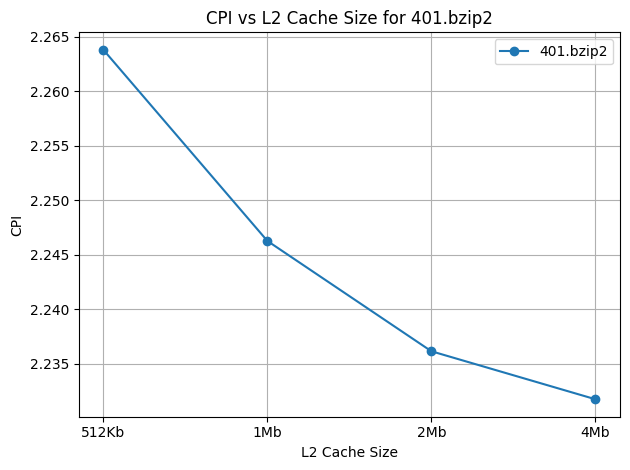

In [ ]:

cache_sizes = ['512Kb', '1Mb', '2Mb', '4Mb']

data = [
    ["401.bzip2",2.2637802066276995,2.2462550020021452,2.2361405781280546,2.231741286000795],
    # ['429.mcf', 1.0525985588737579,1.0509835810151043,1.0493991027383014,1.0472821317619736],
    # ['456.hmmer', 1.0055767058909342,1.005576205892199,1.005576205892199,1.005576205892199],
    # ['458.sjeng', 5.646470868070107,5.646438368126007,5.646431868137187,5.646325868319506],
    # ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022],
]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Cache Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Cache Size for 401.bzip2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2size_graph_401.bzip2.png")
files.download('l2size_graph_401.bzip2.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

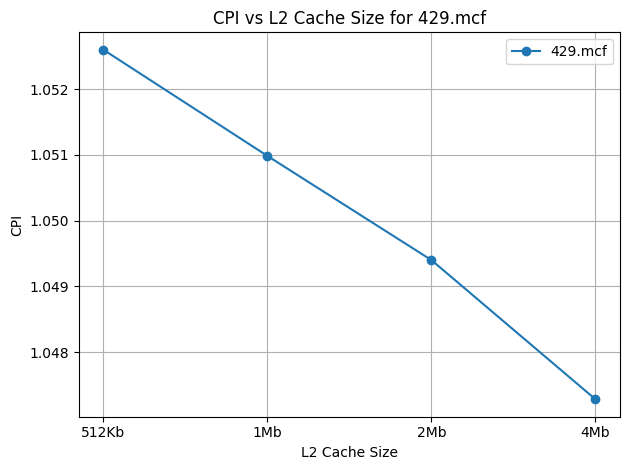

In [ ]:

cache_sizes = ['512Kb', '1Mb', '2Mb', '4Mb']

data = [
    # ["401.bzip2",2.2637802066276995,2.2462550020021452,2.2361405781280546,2.231741286000795],
    ['429.mcf', 1.0525985588737579,1.0509835810151043,1.0493991027383014,1.0472821317619736],
    # ['456.hmmer', 1.0055767058909342,1.005576205892199,1.005576205892199,1.005576205892199],
    # ['458.sjeng', 5.646470868070107,5.646438368126007,5.646431868137187,5.646325868319506],
    # ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022],
]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Cache Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Cache Size for 429.mcf")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2size_graph_429.mcf.png")
files.download('l2size_graph_429.mcf.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

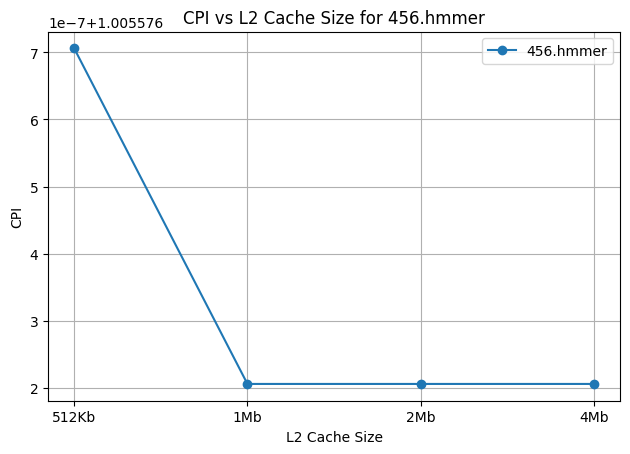

In [ ]:

cache_sizes = ['512Kb', '1Mb', '2Mb', '4Mb']

data = [
    # ["401.bzip2",2.2637802066276995,2.2462550020021452,2.2361405781280546,2.231741286000795],
    # ['429.mcf', 1.0525985588737579,1.0509835810151043,1.0493991027383014,1.0472821317619736],
    ['456.hmmer', 1.0055767058909342,1.005576205892199,1.005576205892199,1.005576205892199],
    # ['458.sjeng', 5.646470868070107,5.646438368126007,5.646431868137187,5.646325868319506],
    # ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022],
]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Cache Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Cache Size for 456.hmmer")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2size_graph_456.hmmer.png")
files.download('l2size_graph_456.hmmer.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

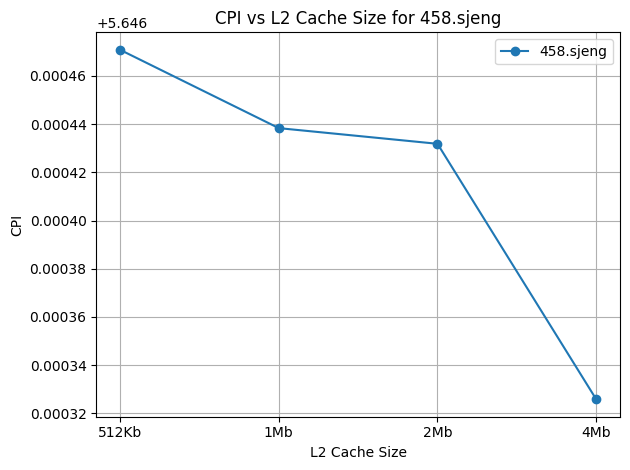

In [ ]:

cache_sizes = ['512Kb', '1Mb', '2Mb', '4Mb']

data = [
    # ["401.bzip2",2.2637802066276995,2.2462550020021452,2.2361405781280546,2.231741286000795],
    # ['429.mcf', 1.0525985588737579,1.0509835810151043,1.0493991027383014,1.0472821317619736],
    # ['456.hmmer', 1.0055767058909342,1.005576205892199,1.005576205892199,1.005576205892199],
     ['458.sjeng', 5.646470868070107,5.646438368126007,5.646431868137187,5.646325868319506],
    # ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022],
]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Cache Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Cache Size for 458.sjeng")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2size_graph_458.hmmer.png")
files.download('l2size_graph_458.hmmer.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

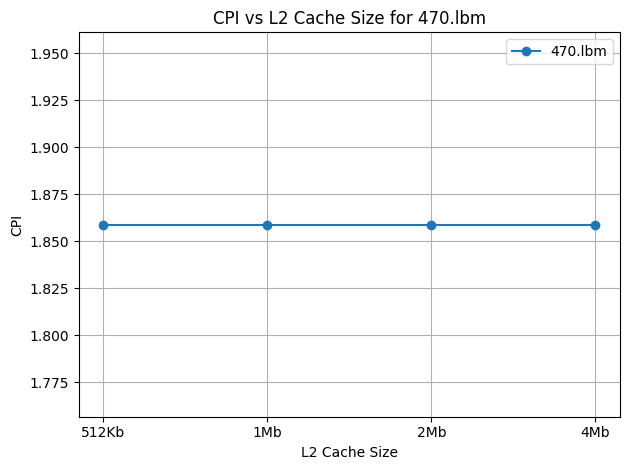

In [ ]:

cache_sizes = ['512Kb', '1Mb', '2Mb', '4Mb']

data = [
    # ["401.bzip2",2.2637802066276995,2.2462550020021452,2.2361405781280546,2.231741286000795],
    # ['429.mcf', 1.0525985588737579,1.0509835810151043,1.0493991027383014,1.0472821317619736],
    # ['456.hmmer', 1.0055767058909342,1.005576205892199,1.005576205892199,1.005576205892199],
    #  ['458.sjeng', 5.646470868070107,5.646438368126007,5.646431868137187,5.646325868319506],
    ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022],
]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Cache Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Cache Size for 470.lbm")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2size_graph_470.lbm.png")
files.download('l2size_graph_470.lbm.png')
plt.show()

[['401.bzip2', 3.3330009767997737, 2.255289467874758, 1.7223185499893168], ['429.mcf', 1.0911320905790383, 1.051924068121026, 1.0287367260194862], ['456.hmmer', 1.0106064131657746, 1.005578705885874, 1.0030279123393817], ['458.sjeng', 10.289351282315794, 5.646579367883487, 3.3253120004633594], ['470.lbm', 2.7177100500673905, 1.8589304769358022, 1.4295190755545375]]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

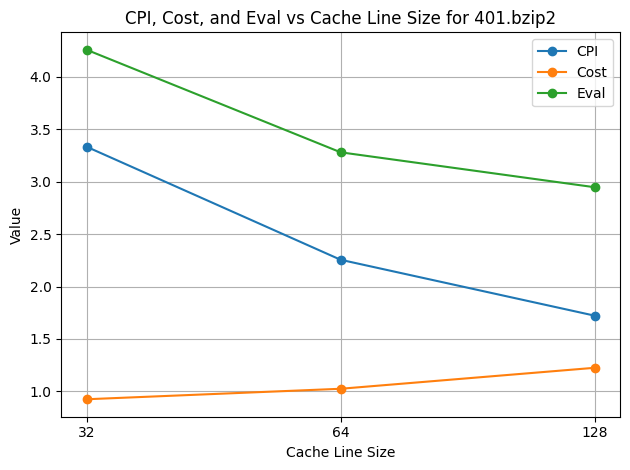

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

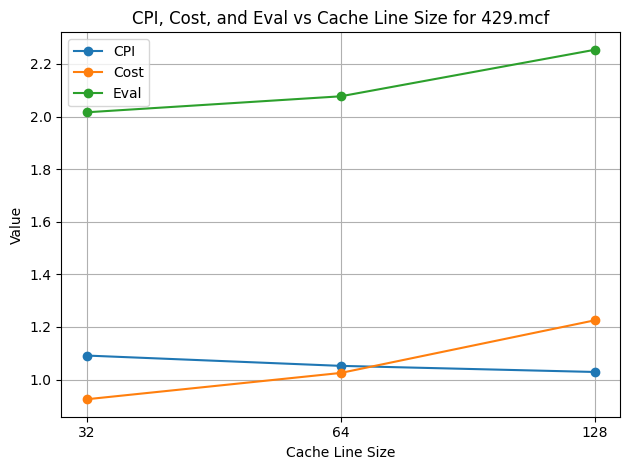

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

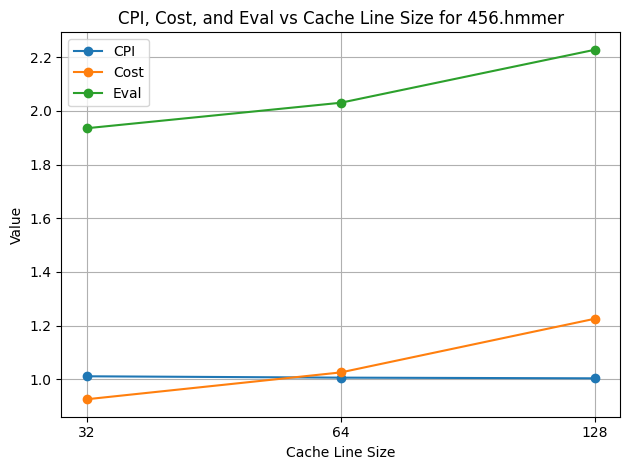

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

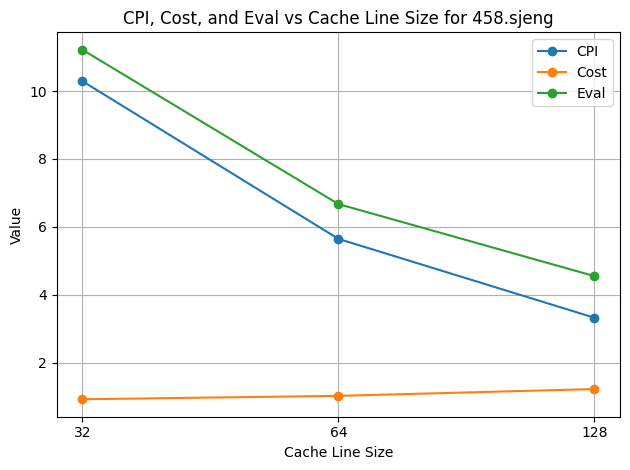

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

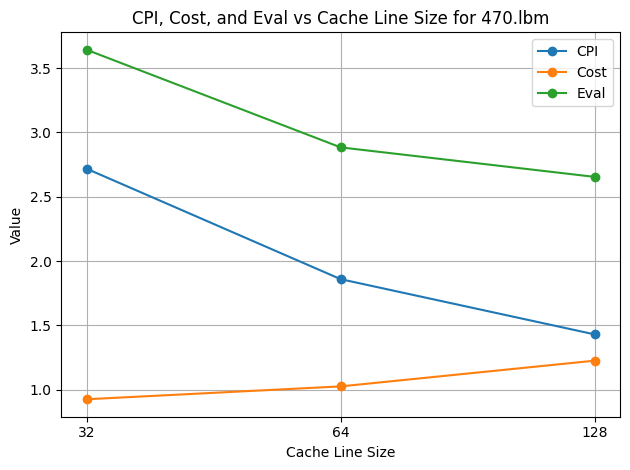

In [59]:
benchmarks = ["401.bzip2", "429.mcf", "456.hmmer", "458.sjeng", "470.lbm"]

cpi_data = []
cost_data = []
eval_data = []
parameters = ["32","64","128"]
for benchmark in benchmarks:
    cpi_row = [benchmark]
    cost_row = [benchmark]
    eval_row = [benchmark]

    for param in parameters:
      cpi_row.append(get_metric(results, "CPI", benchmark, cache_line=param))
      cost_row.append(get_metric(results, "cost", benchmark, cache_line=param))
      eval_row.append(get_metric(results, "eval", benchmark, cache_line=param))

    cpi_data.append(cpi_row)
    cost_data.append(cost_row)
    eval_data.append(eval_row)

print(cpi_data)
plot_all_metrics_for_benchmark("Cache Line Size", parameters, cpi_data, cost_data, eval_data)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

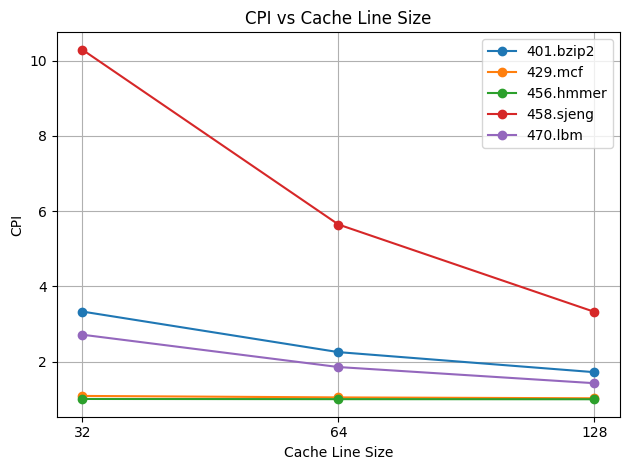

In [ ]:
block_sizes = ["32","64","128"]


data = [
 ['401.bzip2', 3.3330009767997737,2.255289467874758,1.7223185499893168],
 ['429.mcf',1.0911320905790383,1.051924068121026,1.0287367260194862],
 ['456.hmmer',1.0106064131657746,1.005578705885874,1.0030279123393817 ],
 ['458.sjeng',10.289351282315794,5.646579367883487,3.3253120004633594],
 ['470.lbm', 2.7177100500673905,1.8589304769358022,1.4295190755545375]]



for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(block_sizes, values, marker='o', label=benchmark)

plt.xlabel("Cache Line Size")
plt.ylabel("CPI")
plt.title("CPI vs Cache Line Size")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("cacheline_graph.png")
files.download('cacheline_graph.png')
plt.show()

[['401.bzip2', 2.255289467874758, 2.250121561491934, 2.2462550020021452, 2.244911176427886], ['429.mcf', 1.051924068121026, 1.0512610772106314, 1.0509835810151043, 1.0507595840861021], ['456.hmmer', 1.005578705885874, 1.005576205892199, 1.005576205892199, 1.005576205892199], ['458.sjeng', 5.646579367883487, 5.646473368065807, 5.646438368126007, 5.646432368136327], ['470.lbm', 1.8589304769358022, 1.8589304769358022, 1.8589304769358022, 1.8589304769358022]]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

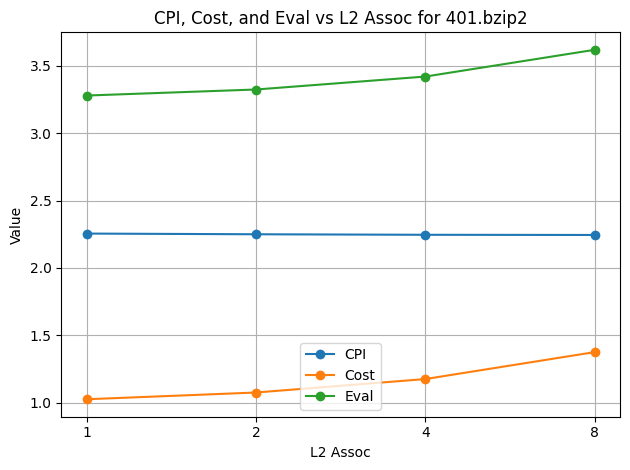

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

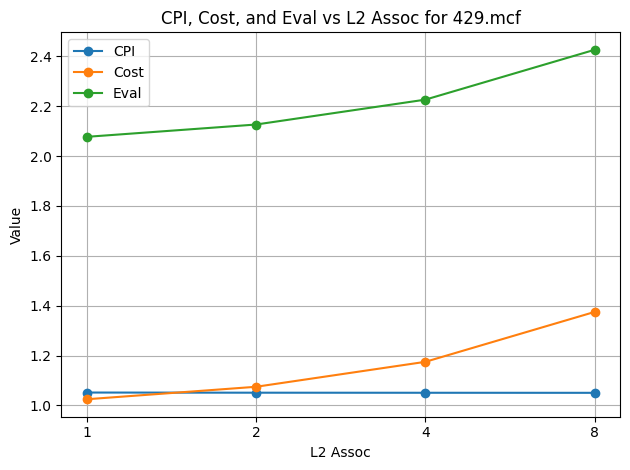

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

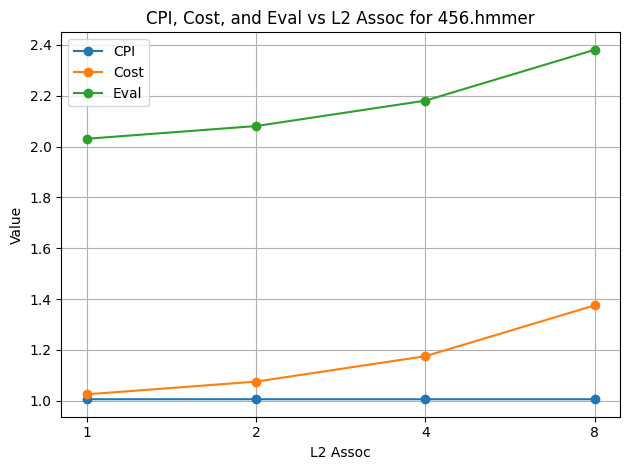

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

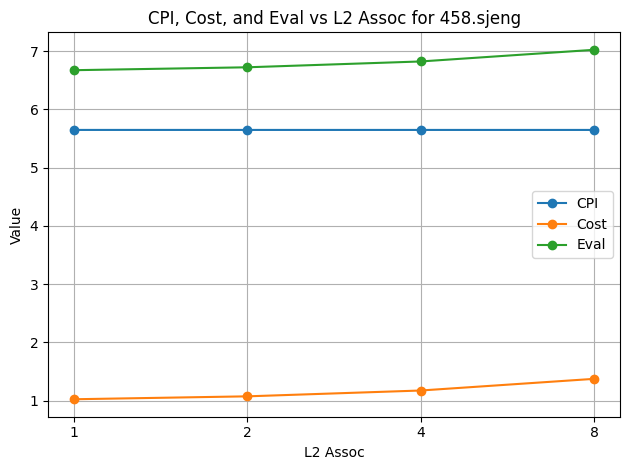

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

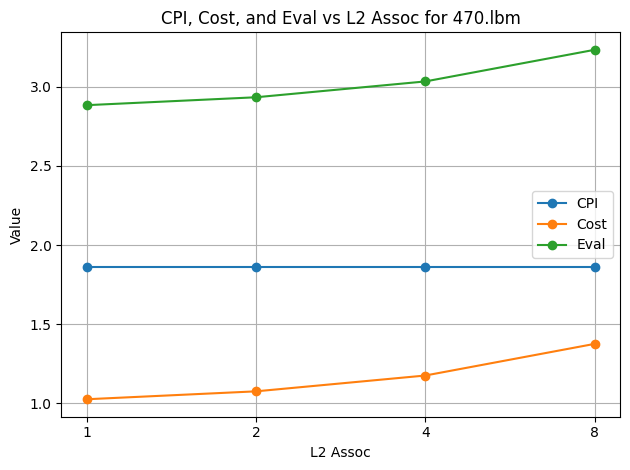

In [62]:
benchmarks = ["401.bzip2", "429.mcf", "456.hmmer", "458.sjeng", "470.lbm"]

cpi_data = []
cost_data = []
eval_data = []
parameters = ['1', '2', '4', '8']
for benchmark in benchmarks:
    cpi_row = [benchmark]
    cost_row = [benchmark]
    eval_row = [benchmark]

    for param in parameters:
      cpi_row.append(get_metric(results, "CPI", benchmark, l2_assoc=param))
      cost_row.append(get_metric(results, "cost", benchmark, l2_assoc=param))
      eval_row.append(get_metric(results, "eval", benchmark, l2_assoc=param))

    cpi_data.append(cpi_row)
    cost_data.append(cost_row)
    eval_data.append(eval_row)

print(cpi_data)
plot_all_metrics_for_benchmark("L2 Assoc", parameters, cpi_data, cost_data, eval_data)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

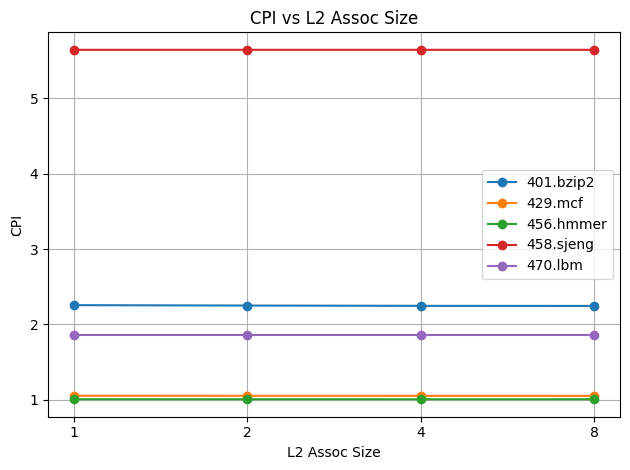

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    ['401.bzip2', 2.255289467874758,2.250121561491934,2.2462550020021452,2.244911176427886],
    ['429.mcf', 1.051924068121026,1.0512610772106314,1.0509835810151043,1.0507595840861021],
    ['456.hmmer', 1.005578705885874,1.005576205892199,1.005576205892199,1.005576205892199],
    ['458.sjeng', 5.646579367883487,5.646473368065807,5.646438368126007,5.646432368136327],
    ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022]]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Assoc Size")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2_assoc_graph.png")
files.download('l2_assoc_graph.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

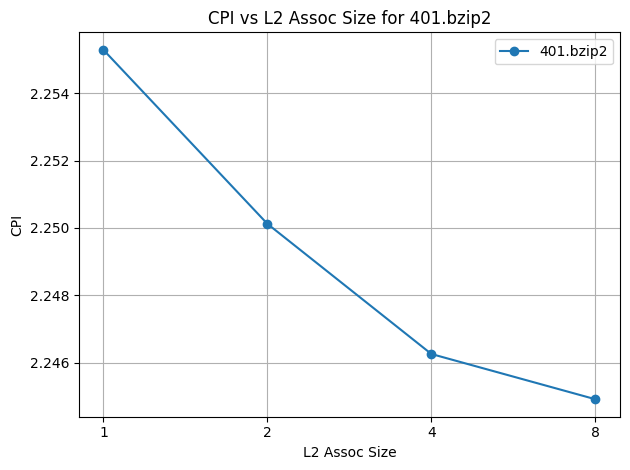

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    ['401.bzip2', 2.255289467874758,2.250121561491934,2.2462550020021452,2.244911176427886],
    # ['429.mcf', 1.051924068121026,1.0512610772106314,1.0509835810151043,1.0507595840861021],
    # ['456.hmmer', 1.005578705885874,1.005576205892199,1.005576205892199,1.005576205892199],
    # ['458.sjeng', 5.646579367883487,5.646473368065807,5.646438368126007,5.646432368136327],
    # ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Assoc Size for 401.bzip2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2_assoc_graph_401.bzip2.png")
files.download('l2_assoc_graph_401.bzip2.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

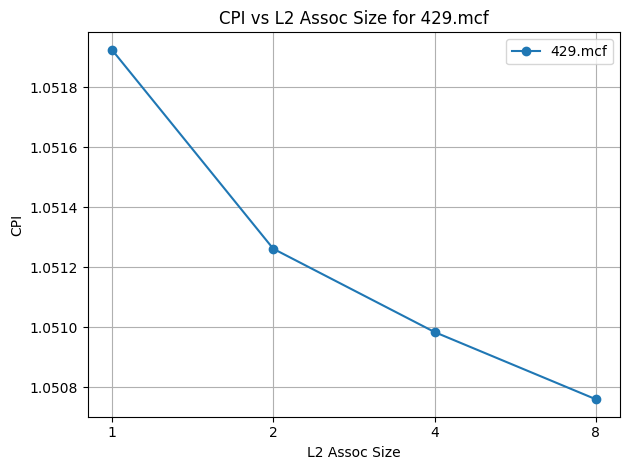

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    # ['401.bzip2', 2.255289467874758,2.250121561491934,2.2462550020021452,2.244911176427886],
     ['429.mcf', 1.051924068121026,1.0512610772106314,1.0509835810151043,1.0507595840861021],
    # ['456.hmmer', 1.005578705885874,1.005576205892199,1.005576205892199,1.005576205892199],
    # ['458.sjeng', 5.646579367883487,5.646473368065807,5.646438368126007,5.646432368136327],
    # ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Assoc Size for 429.mcf")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2_assoc_graph_429.mcf.png")
files.download('l2_assoc_graph_429.mcf.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

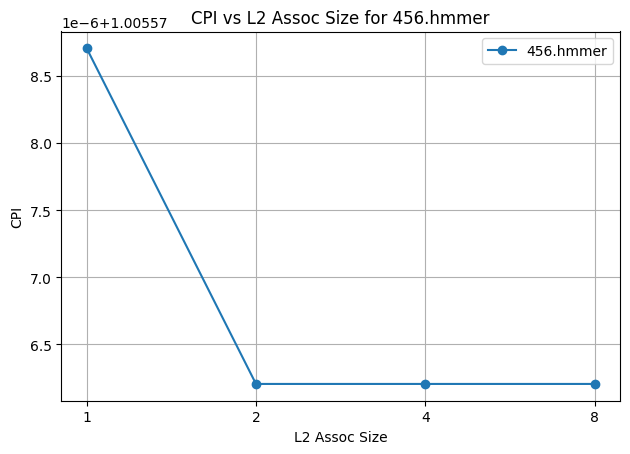

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    # ['401.bzip2', 2.255289467874758,2.250121561491934,2.2462550020021452,2.244911176427886],
    #  ['429.mcf', 1.051924068121026,1.0512610772106314,1.0509835810151043,1.0507595840861021],
     ['456.hmmer', 1.005578705885874,1.005576205892199,1.005576205892199,1.005576205892199],
    # ['458.sjeng', 5.646579367883487,5.646473368065807,5.646438368126007,5.646432368136327],
    # ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Assoc Size for 456.hmmer")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2_assoc_graph_456.hmmer.png")
files.download('l2_assoc_graph_456.hmmer.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

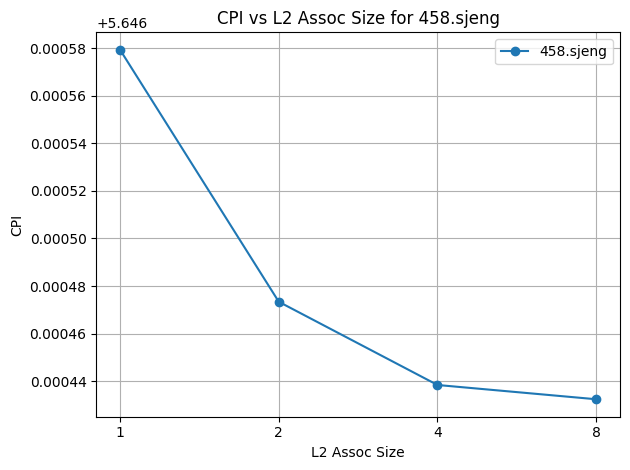

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    # ['401.bzip2', 2.255289467874758,2.250121561491934,2.2462550020021452,2.244911176427886],
    #  ['429.mcf', 1.051924068121026,1.0512610772106314,1.0509835810151043,1.0507595840861021],
    #  ['456.hmmer', 1.005578705885874,1.005576205892199,1.005576205892199,1.005576205892199],
    ['458.sjeng', 5.646579367883487,5.646473368065807,5.646438368126007,5.646432368136327],
    # ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Assoc Size for 458.sjeng")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2_assoc_graph_458.sjeng.png")
files.download('l2_assoc_graph_458.sjeng.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

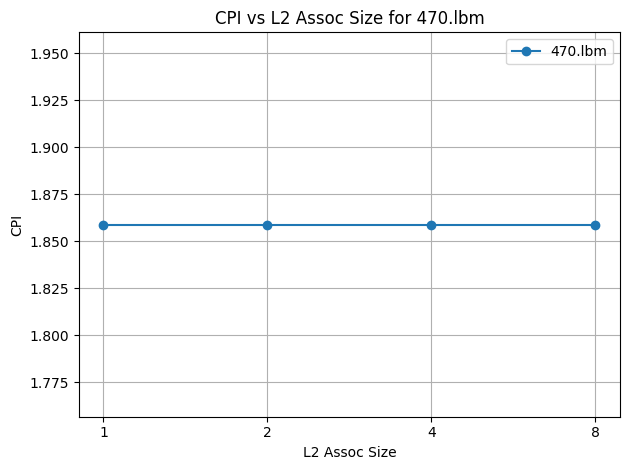

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    # ['401.bzip2', 2.255289467874758,2.250121561491934,2.2462550020021452,2.244911176427886],
    #  ['429.mcf', 1.051924068121026,1.0512610772106314,1.0509835810151043,1.0507595840861021],
    #  ['456.hmmer', 1.005578705885874,1.005576205892199,1.005576205892199,1.005576205892199],
    # ['458.sjeng', 5.646579367883487,5.646473368065807,5.646438368126007,5.646432368136327],
    ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Assoc Size for 470.lbm")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2_assoc_graph_470.lbm.png")
files.download('l2_assoc_graph_470.lbm.png')
plt.show()

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    ['401.bzip2', 2.255289467874758,2.250121561491934,2.2462550020021452,2.244911176427886],
    ['429.mcf', 1.051924068121026,1.0512610772106314,1.0509835810151043,1.0507595840861021],
    ['456.hmmer', 1.005578705885874,1.005576205892199,1.005576205892199,1.005576205892199],
    ['458.sjeng', 5.646579367883487,5.646473368065807,5.646438368126007,5.646432368136327],
    ['470.lbm', 1.8589304769358022,1.8589304769358022,1.8589304769358022,1.8589304769358022]]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L2 Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L2 Assoc Size")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l2_assoc_graph.png")
files.download('l2_assoc_graph.png')
plt.show()

[['401.bzip2', 2.258442725349429, 2.255289467874758, 2.2534902708377746, 2.2516989898279753], ['429.mcf', 1.0529049546730713, 1.051924068121026, 1.051718610937844, 1.0516015525427147], ['456.hmmer', 1.0072846815697556, 1.005578705885874, 1.0051677669255497, 1.0052359267531052], ['458.sjeng', 5.647985565464827, 5.646579367883487, 5.646467948075129, 5.646432108136774], ['470.lbm', 1.8596033955295481, 1.8589304769358022, 1.8589303569645783, 1.8589303569645783]]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

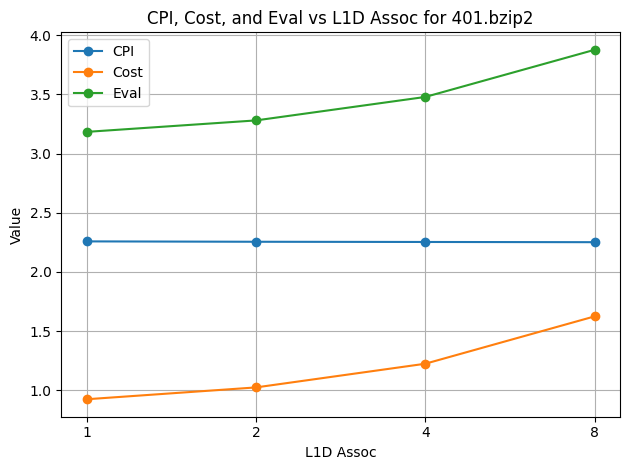

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

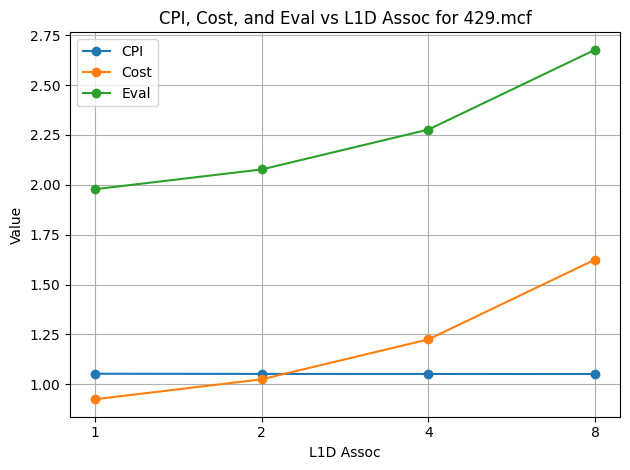

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

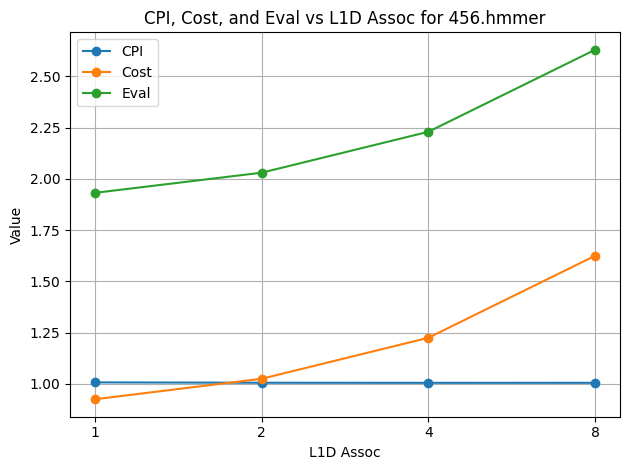

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

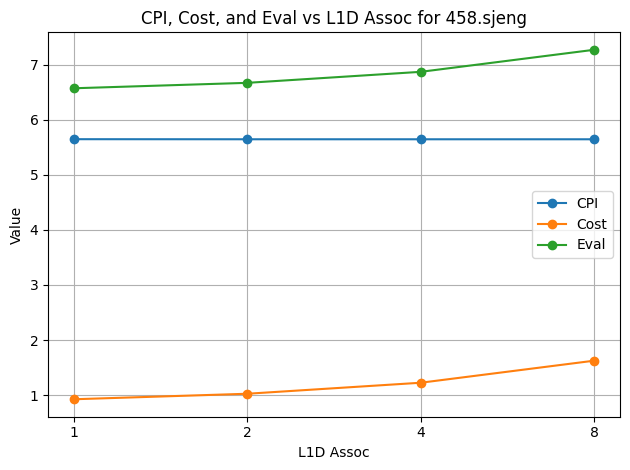

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

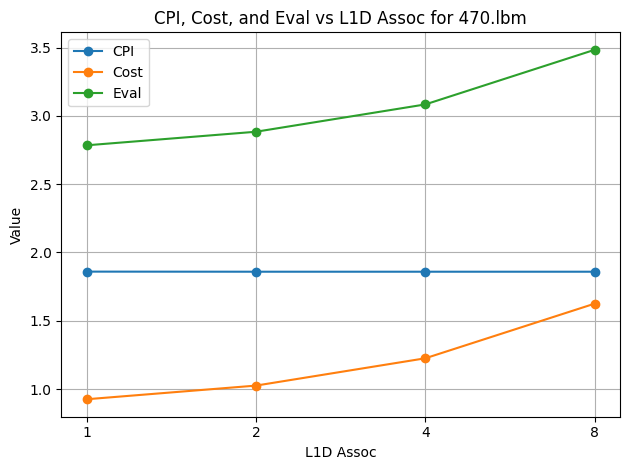

In [64]:
benchmarks = ["401.bzip2", "429.mcf", "456.hmmer", "458.sjeng", "470.lbm"]

cpi_data = []
cost_data = []
eval_data = []
parameters = ['1', '2', '4', '8']
for benchmark in benchmarks:
    cpi_row = [benchmark]
    cost_row = [benchmark]
    eval_row = [benchmark]

    for param in parameters:
      cpi_row.append(get_metric(results, "CPI", benchmark, l1d_assoc=param))
      cost_row.append(get_metric(results, "cost", benchmark, l1d_assoc=param))
      eval_row.append(get_metric(results, "eval", benchmark, l1d_assoc=param))

    cpi_data.append(cpi_row)
    cost_data.append(cost_row)
    eval_data.append(eval_row)

print(cpi_data)
plot_all_metrics_for_benchmark("L1D Assoc", parameters, cpi_data, cost_data, eval_data)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

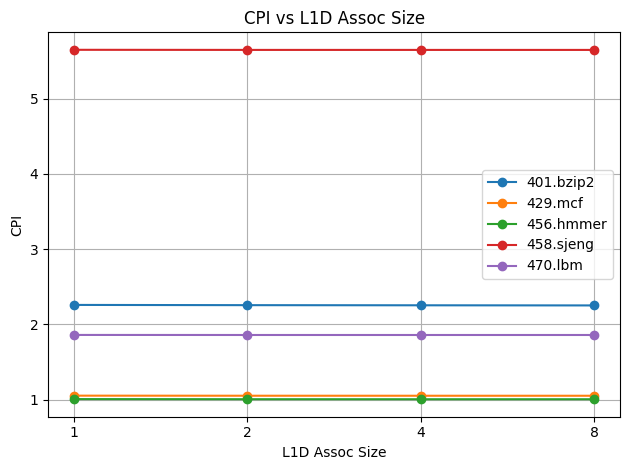

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    ['401.bzip2', 2.258442725349429,2.255289467874758,2.2534902708377746,2.2516989898279753],
    ['429.mcf', 1.0529049546730713,1.051924068121026,1.051718610937844,1.0516015525427147],
    ['456.hmmer', 1.0072846815697556,1.005578705885874,1.0051677669255497,1.0052359267531052],
    ['458.sjeng',5.647985565464827,5.646579367883487,5.646467948075129,5.646432108136774],
    ['470.lbm', 1.8596033955295481,1.8589304769358022,1.8589303569645783,1.8589303569645783]]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1D Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1D Assoc Size")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1d_assoc_graph.png")
files.download('l1d_assoc_graph.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

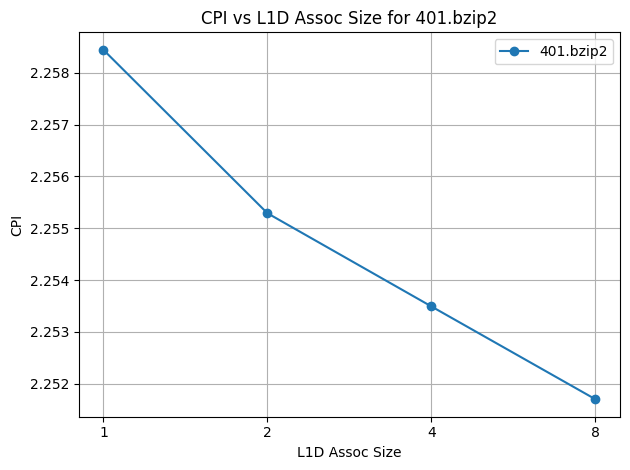

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    ['401.bzip2', 2.258442725349429,2.255289467874758,2.2534902708377746,2.2516989898279753],
    # ['429.mcf', 1.0529049546730713,1.051924068121026,1.051718610937844,1.0516015525427147],
    # ['456.hmmer', 1.0072846815697556,1.005578705885874,1.0051677669255497,1.0052359267531052],
    # ['458.sjeng',5.647985565464827,5.646579367883487,5.646467948075129,5.646432108136774],
    # ['470.lbm', 1.8596033955295481,1.8589304769358022,1.8589303569645783,1.8589303569645783]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1D Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1D Assoc Size for 401.bzip2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1d_assoc_graph_401.bzip2.png")
files.download('l1d_assoc_graph_401.bzip2.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

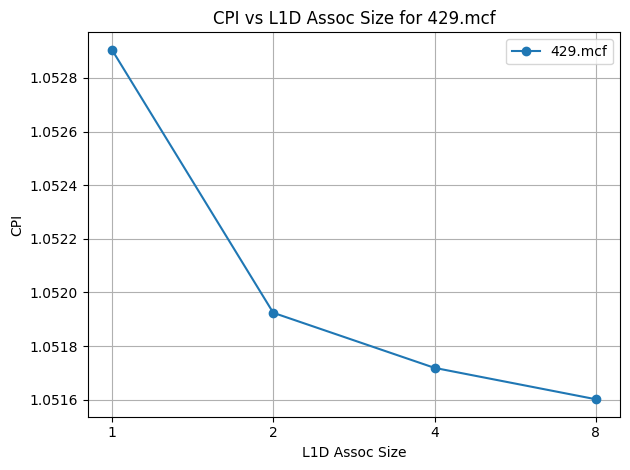

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    # ['401.bzip2', 2.258442725349429,2.255289467874758,2.2534902708377746,2.2516989898279753],
     ['429.mcf', 1.0529049546730713,1.051924068121026,1.051718610937844,1.0516015525427147],
    # ['456.hmmer', 1.0072846815697556,1.005578705885874,1.0051677669255497,1.0052359267531052],
    # ['458.sjeng',5.647985565464827,5.646579367883487,5.646467948075129,5.646432108136774],
    # ['470.lbm', 1.8596033955295481,1.8589304769358022,1.8589303569645783,1.8589303569645783]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1D Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1D Assoc Size for 429.mcf")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1d_assoc_graph_429.mcf.png")
files.download('l1d_assoc_graph_429.mcf.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

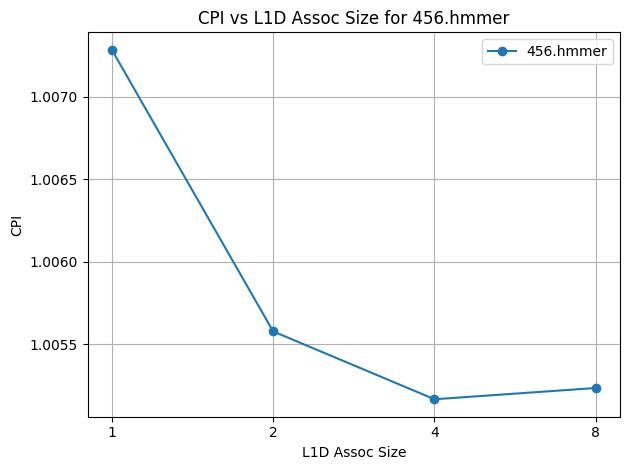

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    # ['401.bzip2', 2.258442725349429,2.255289467874758,2.2534902708377746,2.2516989898279753],
    #  ['429.mcf', 1.0529049546730713,1.051924068121026,1.051718610937844,1.0516015525427147],
     ['456.hmmer', 1.0072846815697556,1.005578705885874,1.0051677669255497,1.0052359267531052],
    # ['458.sjeng',5.647985565464827,5.646579367883487,5.646467948075129,5.646432108136774],
    # ['470.lbm', 1.8596033955295481,1.8589304769358022,1.8589303569645783,1.8589303569645783]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1D Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1D Assoc Size for 456.hmmer")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1d_assoc_graph_456.hmmer.png")
files.download('l1d_assoc_graph_456.hmmer.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

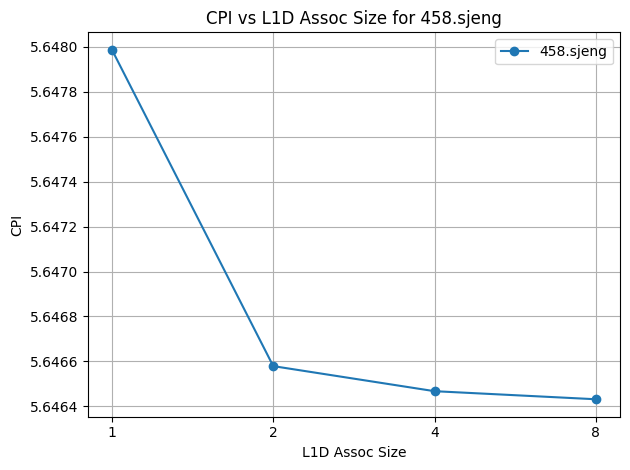

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    # ['401.bzip2', 2.258442725349429,2.255289467874758,2.2534902708377746,2.2516989898279753],
    #  ['429.mcf', 1.0529049546730713,1.051924068121026,1.051718610937844,1.0516015525427147],
    #  ['456.hmmer', 1.0072846815697556,1.005578705885874,1.0051677669255497,1.0052359267531052],
     ['458.sjeng',5.647985565464827,5.646579367883487,5.646467948075129,5.646432108136774],
    # ['470.lbm', 1.8596033955295481,1.8589304769358022,1.8589303569645783,1.8589303569645783]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1D Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1D Assoc Size for 458.sjeng")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1d_assoc_graph_458.sjeng.png")
files.download('l1d_assoc_graph_458.sjeng.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

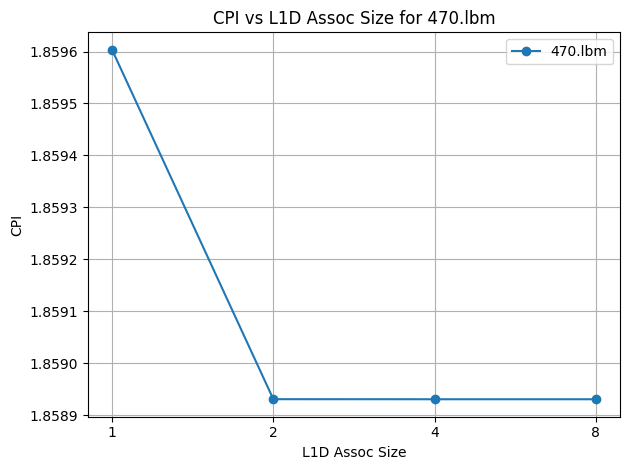

In [ ]:
assoc_sizes = ['1', '2', '4', '8']

data = [
    # ['401.bzip2', 2.258442725349429,2.255289467874758,2.2534902708377746,2.2516989898279753],
    #  ['429.mcf', 1.0529049546730713,1.051924068121026,1.051718610937844,1.0516015525427147],
    #  ['456.hmmer', 1.0072846815697556,1.005578705885874,1.0051677669255497,1.0052359267531052],
    #  ['458.sjeng',5.647985565464827,5.646579367883487,5.646467948075129,5.646432108136774],
     ['470.lbm', 1.8596033955295481,1.8589304769358022,1.8589303569645783,1.8589303569645783]
]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1D Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1D Assoc Size for 470.lbm")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1d_assoc_graph_470.lbm.png")
files.download('l1d_assoc_graph_470.lbm.png')
plt.show()

[['401.bzip2', 2.255297823681229, 2.255289467874758, 2.255289467874758, 2.255289467874758], ['429.mcf', 1.0519244281160904, 1.051924068121026, 1.051924068121026, 1.051924068121026], ['456.hmmer', 1.0057186255318773, 1.005578705885874, 1.0055782258870885, 1.005578105887392], ['458.sjeng', 5.646671787724525, 5.646579367883487, 5.64654280794637, 5.646535927958204], ['470.lbm', 1.85893137671998, 1.8589304769358022, 1.8589304769358022, 1.8589304769358022]]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

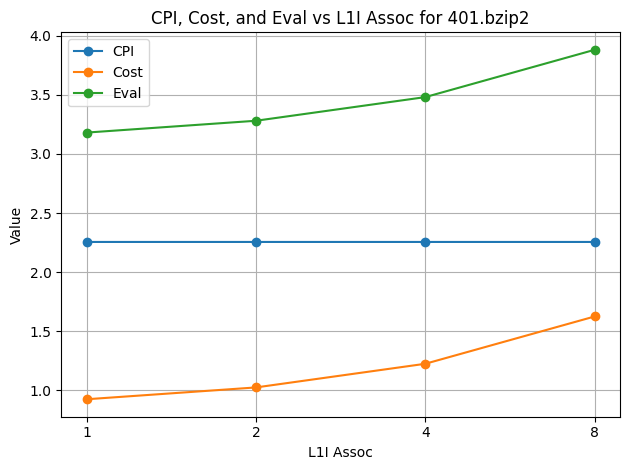

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

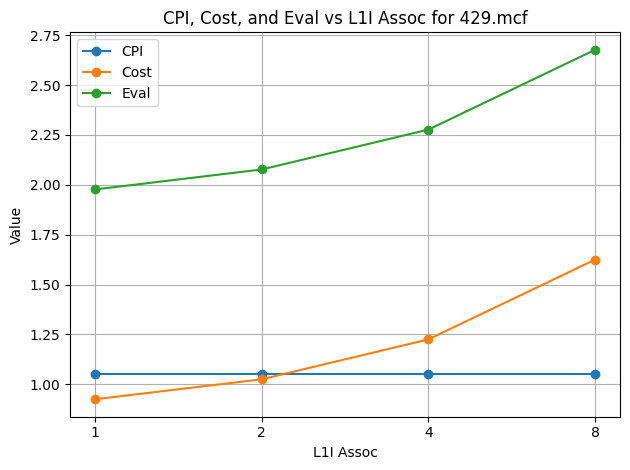

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

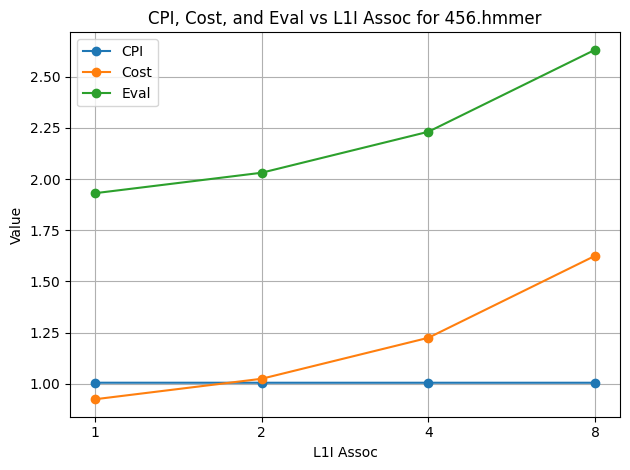

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

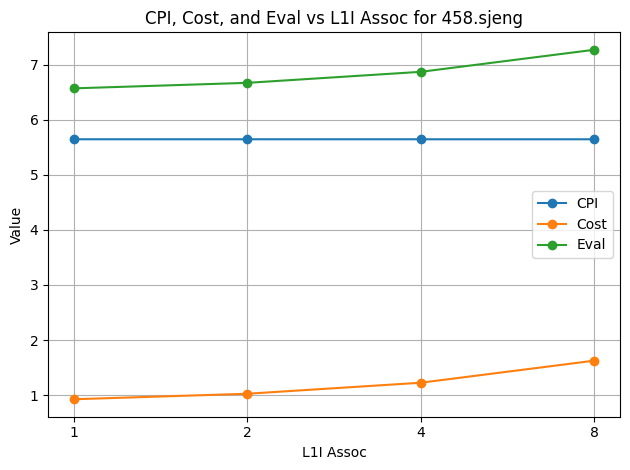

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

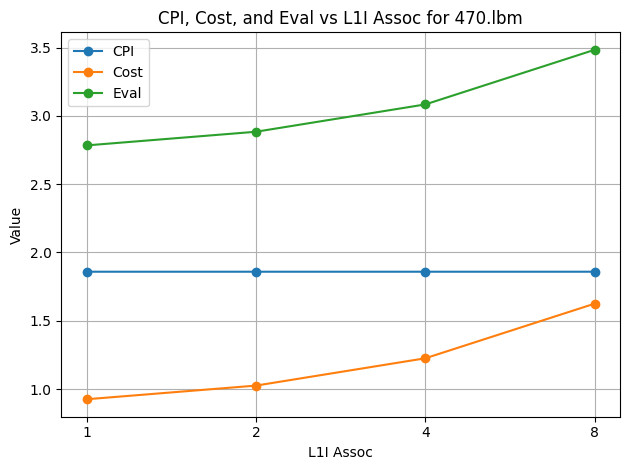

In [73]:
benchmarks = ["401.bzip2", "429.mcf", "456.hmmer", "458.sjeng", "470.lbm"]

cpi_data = []
cost_data = []
eval_data = []
parameters = ['1', '2', '4', '8']
for benchmark in benchmarks:
    cpi_row = [benchmark]
    cost_row = [benchmark]
    eval_row = [benchmark]

    for param in parameters:
      cpi_row.append(get_metric(results, "CPI", benchmark, l1i_assoc=param))
      cost_row.append(get_metric(results, "cost", benchmark, l1i_assoc=param))
      eval_row.append(get_metric(results, "eval", benchmark, l1i_assoc=param))

    cpi_data.append(cpi_row)
    cost_data.append(cost_row)
    eval_data.append(eval_row)

print(cpi_data)
plot_all_metrics_for_benchmark("L1I Assoc", parameters, cpi_data, cost_data, eval_data)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

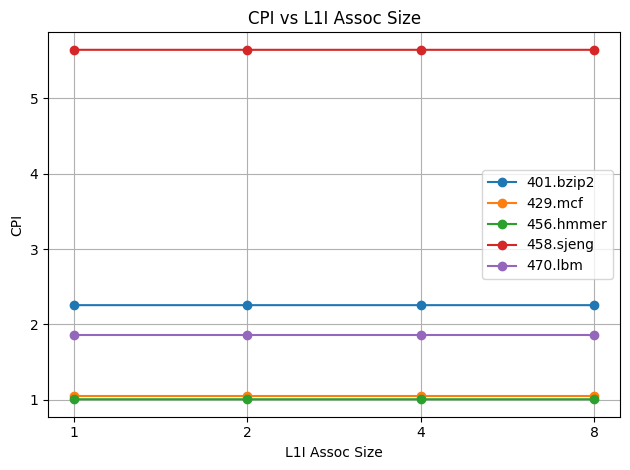

In [ ]:
assoc_sizes = ['1', '2', '4', '8']


data = [
    ['401.bzip2',2.255297823681229,2.255289467874758,2.255289467874758,2.255289467874758],
    ['429.mcf',1.0519244281160904,1.051924068121026,1.051924068121026,1.051924068121026],
    ['456.hmmer',1.0057186255318773,1.005578705885874,1.0055782258870885,1.005578105887392],
    ['458.sjeng',5.646671787724525,5.646579367883487,5.64654280794637,5.646535927958204],
    ['470.lbm', 1.85893137671998,1.8589304769358022,1.8589304769358022,1.8589304769358022]]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1I Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1I Assoc Size")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1i_assoc_graph.png")
files.download('l1i_assoc_graph.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

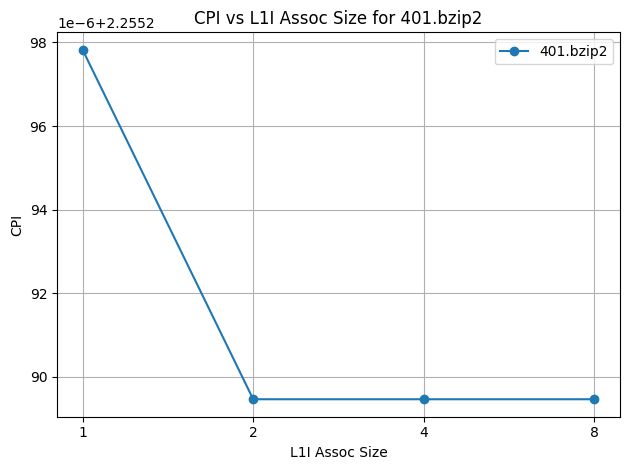

In [ ]:
assoc_sizes = ['1', '2', '4', '8']


data = [
    ['401.bzip2',2.255297823681229,2.255289467874758,2.255289467874758,2.255289467874758],
    # ['429.mcf',1.0519244281160904,1.051924068121026,1.051924068121026,1.051924068121026],
    # ['456.hmmer',1.0057186255318773,1.005578705885874,1.0055782258870885,1.005578105887392],
    # ['458.sjeng',5.646671787724525,5.646579367883487,5.64654280794637,5.646535927958204],
    # ['470.lbm', 1.85893137671998,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1I Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1I Assoc Size for 401.bzip2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1i_assoc_graph_401.bzip2.png")
files.download('l1i_assoc_graph_401.bzip2.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

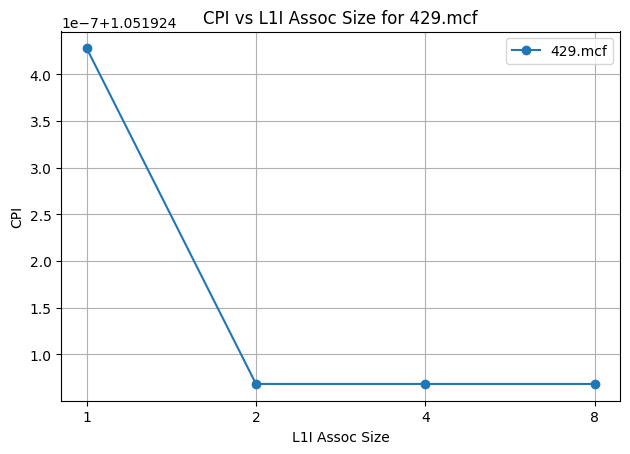

In [ ]:
assoc_sizes = ['1', '2', '4', '8']


data = [
    # ['401.bzip2',2.255297823681229,2.255289467874758,2.255289467874758,2.255289467874758],
     ['429.mcf',1.0519244281160904,1.051924068121026,1.051924068121026,1.051924068121026],
    # ['456.hmmer',1.0057186255318773,1.005578705885874,1.0055782258870885,1.005578105887392],
    # ['458.sjeng',5.646671787724525,5.646579367883487,5.64654280794637,5.646535927958204],
    # ['470.lbm', 1.85893137671998,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1I Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1I Assoc Size for 429.mcf")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1i_assoc_graph_429.mcf.png")
files.download('l1i_assoc_graph_429.mcf.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

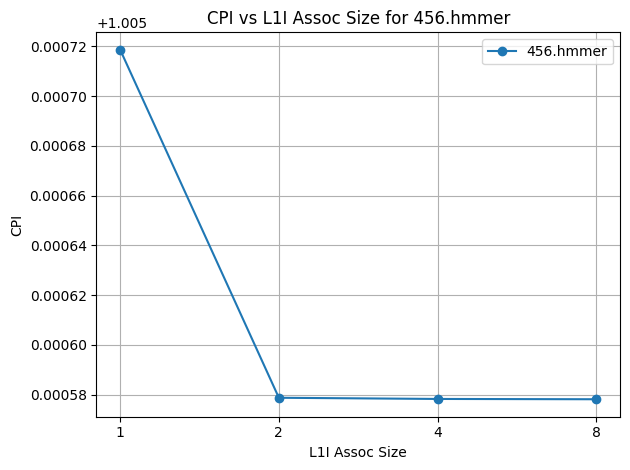

In [ ]:
assoc_sizes = ['1', '2', '4', '8']


data = [
    # ['401.bzip2',2.255297823681229,2.255289467874758,2.255289467874758,2.255289467874758],
    #  ['429.mcf',1.0519244281160904,1.051924068121026,1.051924068121026,1.051924068121026],
     ['456.hmmer',1.0057186255318773,1.005578705885874,1.0055782258870885,1.005578105887392],
    # ['458.sjeng',5.646671787724525,5.646579367883487,5.64654280794637,5.646535927958204],
    # ['470.lbm', 1.85893137671998,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1I Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1I Assoc Size for 456.hmmer")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1i_assoc_graph_456.hmmer.png")
files.download('l1i_assoc_graph_456.hmmer.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

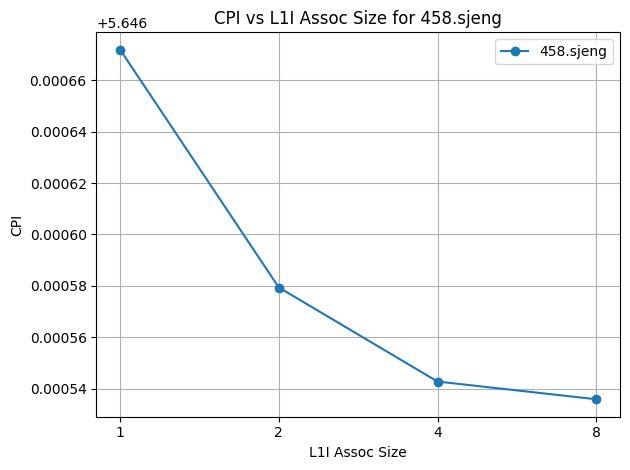

In [ ]:
assoc_sizes = ['1', '2', '4', '8']


data = [
    # ['401.bzip2',2.255297823681229,2.255289467874758,2.255289467874758,2.255289467874758],
    #  ['429.mcf',1.0519244281160904,1.051924068121026,1.051924068121026,1.051924068121026],
    #  ['456.hmmer',1.0057186255318773,1.005578705885874,1.0055782258870885,1.005578105887392],
     ['458.sjeng',5.646671787724525,5.646579367883487,5.64654280794637,5.646535927958204],
    # ['470.lbm', 1.85893137671998,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1I Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1I Assoc Size for 458.sjeng")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1i_assoc_graph_458.sjeng.png")
files.download('l1i_assoc_graph_458.sjeng.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

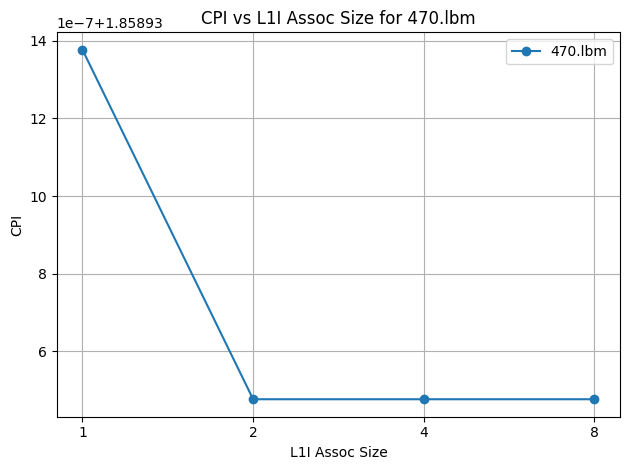

In [ ]:
assoc_sizes = ['1', '2', '4', '8']


data = [
    # ['401.bzip2',2.255297823681229,2.255289467874758,2.255289467874758,2.255289467874758],
    #  ['429.mcf',1.0519244281160904,1.051924068121026,1.051924068121026,1.051924068121026],
    #  ['456.hmmer',1.0057186255318773,1.005578705885874,1.0055782258870885,1.005578105887392],
    #  ['458.sjeng',5.646671787724525,5.646579367883487,5.64654280794637,5.646535927958204],
     ['470.lbm', 1.85893137671998,1.8589304769358022,1.8589304769358022,1.8589304769358022]
    ]

for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(assoc_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1I Assoc Size")
plt.ylabel("CPI")
plt.title("CPI vs L1I Assoc Size for 470.lbm")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1i_assoc_graph_470.lbm.png")
files.download('l1i_assoc_graph_470.lbm.png')
plt.show()

[['401.bzip2', 2.255289467874758, 2.242906422553713, 2.242906422553713], ['429.mcf', 1.051924068121026, 1.0516173523260997, 1.0516173523260997], ['456.hmmer', 1.005578705885874, 1.0036350508033214, 1.0036345108046876], ['458.sjeng', 5.646579367883487, 5.646358088264088, 5.646315148337945], ['470.lbm', 1.8589304769358022, 1.8589303569645783, 1.8589303569645783]]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

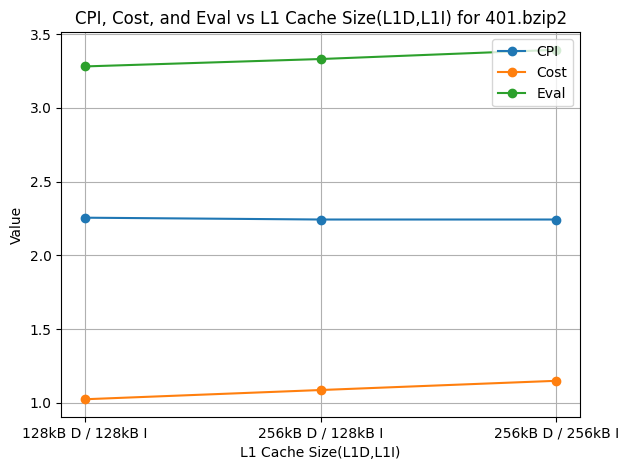

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

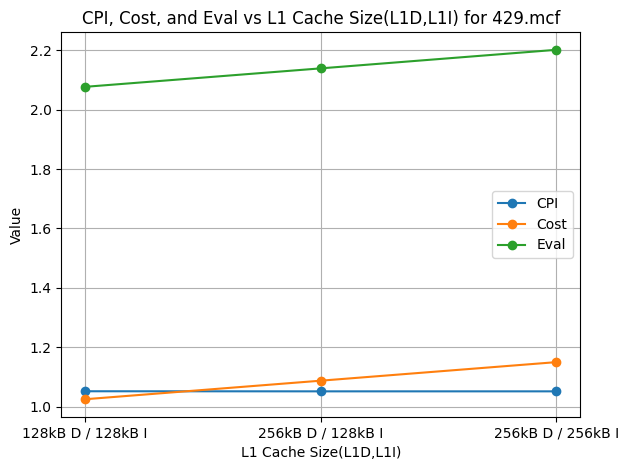

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

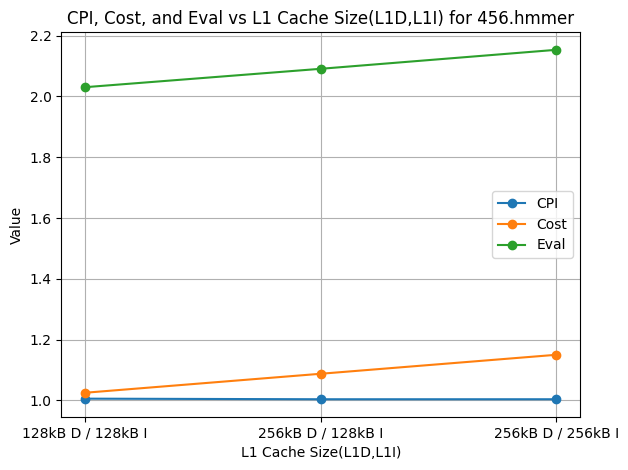

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

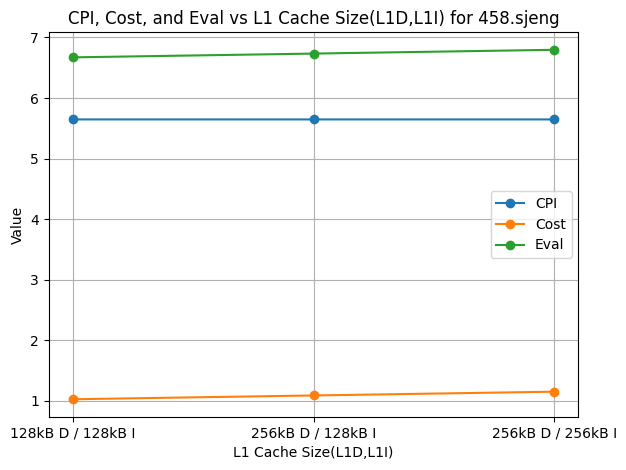

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

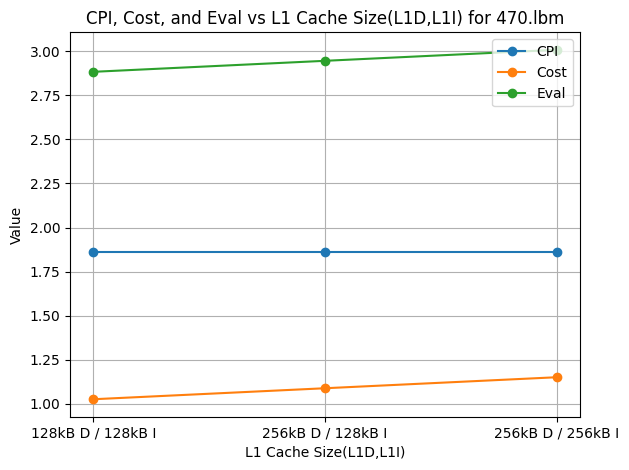

In [72]:
benchmarks = ["401.bzip2", "429.mcf", "456.hmmer", "458.sjeng", "470.lbm"]

cpi_data = []
cost_data = []
eval_data = []
x_vals =['128kB D / 128kB I', '256kB D / 128kB I', '256kB D / 256kB I']
parameters=[ ('128kB', '128kB'), ('256kB','128kB'), ('256kB','256kB')]
for benchmark in benchmarks:
    cpi_row = [benchmark]
    cost_row = [benchmark]
    eval_row = [benchmark]

    for param in parameters:
      cpi_row.append(get_metric(results, "CPI", benchmark, l1i_size=param[1], l1d_size=param[0]))
      cost_row.append(get_metric(results, "cost", benchmark, l1i_size=param[1], l1d_size=param[0]))
      eval_row.append(get_metric(results, "eval", benchmark, l1i_size=param[1], l1d_size=param[0]))

    cpi_data.append(cpi_row)
    cost_data.append(cost_row)
    eval_data.append(eval_row)

print(cpi_data)
plot_all_metrics_for_benchmark("L1 Cache Size(L1D,L1I)", x_vals, cpi_data, cost_data, eval_data)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

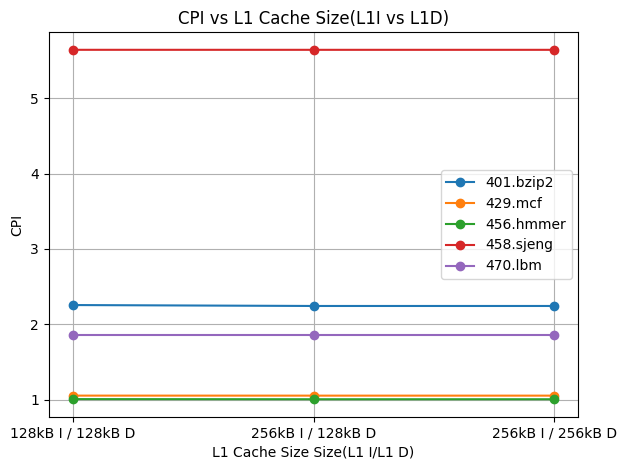

In [ ]:
cache_sizes = ['128kB I / 128kB D', '256kB I / 128kB D', '256kB I / 256kB D']


data = [
    ['401.bzip2',2.255289467874758,2.242906422553713,2.242906422553713],
    ['429.mcf',1.051924068121026,1.0516173523260997,1.0516173523260997],
    ['456.hmmer',1.005578705885874,1.0036350508033214,1.0036345108046876],
    ['458.sjeng',5.646579367883487,5.646358088264088,5.646315148337945],
    ['470.lbm', 1.8589304769358022,1.8589303569645783,1.8589303569645783]]


for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1 Cache Size Size(L1 I/L1 D)")
plt.ylabel("CPI")
plt.title("CPI vs L1 Cache Size(L1I vs L1D)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1size_graph.png")
files.download('l1size_graph.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

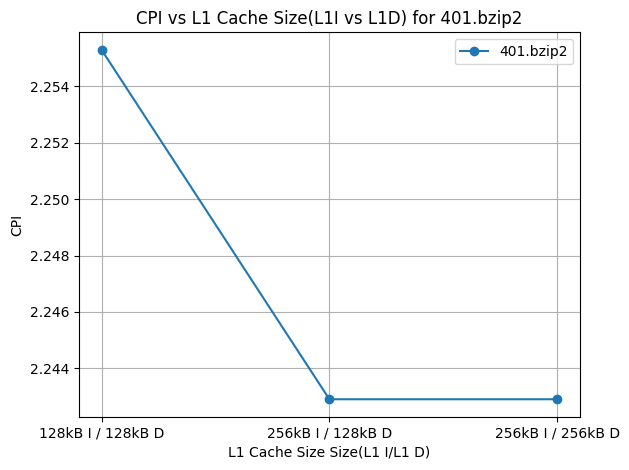

In [ ]:
cache_sizes = ['128kB I / 128kB D', '256kB I / 128kB D', '256kB I / 256kB D']


data = [
    ['401.bzip2',2.255289467874758,2.242906422553713,2.242906422553713],
    # ['429.mcf',1.051924068121026,1.0516173523260997,1.0516173523260997],
    # ['456.hmmer',1.005578705885874,1.0036350508033214,1.0036345108046876],
    # ['458.sjeng',5.646579367883487,5.646358088264088,5.646315148337945],
    # ['470.lbm', 1.8589304769358022,1.8589303569645783,1.8589303569645783]
    ]


for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1 Cache Size Size(L1 I/L1 D)")
plt.ylabel("CPI")
plt.title("CPI vs L1 Cache Size(L1I vs L1D) for 401.bzip2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1size_graph_401.bzip2.png")
files.download('l1size_graph_401.bzip2.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

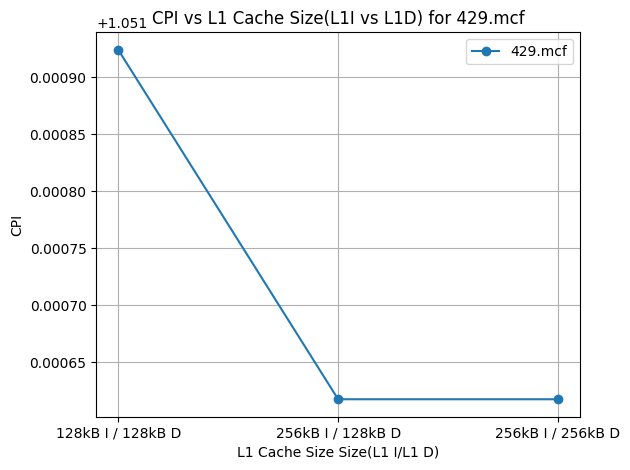

In [ ]:
cache_sizes = ['128kB I / 128kB D', '256kB I / 128kB D', '256kB I / 256kB D']


data = [
    # ['401.bzip2',2.255289467874758,2.242906422553713,2.242906422553713],
    ['429.mcf',1.051924068121026,1.0516173523260997,1.0516173523260997],
    # ['456.hmmer',1.005578705885874,1.0036350508033214,1.0036345108046876],
    # ['458.sjeng',5.646579367883487,5.646358088264088,5.646315148337945],
    # ['470.lbm', 1.8589304769358022,1.8589303569645783,1.8589303569645783]
    ]


for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1 Cache Size Size(L1 I/L1 D)")
plt.ylabel("CPI")
plt.title("CPI vs L1 Cache Size(L1I vs L1D) for 429.mcf")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1size_graph_429.mcf.png")
files.download('l1size_graph_429.mcf.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

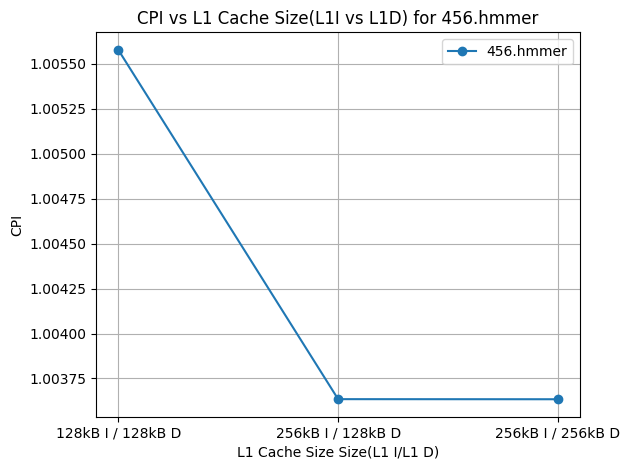

In [ ]:
cache_sizes = ['128kB I / 128kB D', '256kB I / 128kB D', '256kB I / 256kB D']


data = [
    # ['401.bzip2',2.255289467874758,2.242906422553713,2.242906422553713],
    # ['429.mcf',1.051924068121026,1.0516173523260997,1.0516173523260997],
    ['456.hmmer',1.005578705885874,1.0036350508033214,1.0036345108046876],
    # ['458.sjeng',5.646579367883487,5.646358088264088,5.646315148337945],
    # ['470.lbm', 1.8589304769358022,1.8589303569645783,1.8589303569645783]
    ]


for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1 Cache Size Size(L1 I/L1 D)")
plt.ylabel("CPI")
plt.title("CPI vs L1 Cache Size(L1I vs L1D) for 456.hmmer")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1size_graph_456.hmmer.png")
files.download('l1size_graph_456.hmmer.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

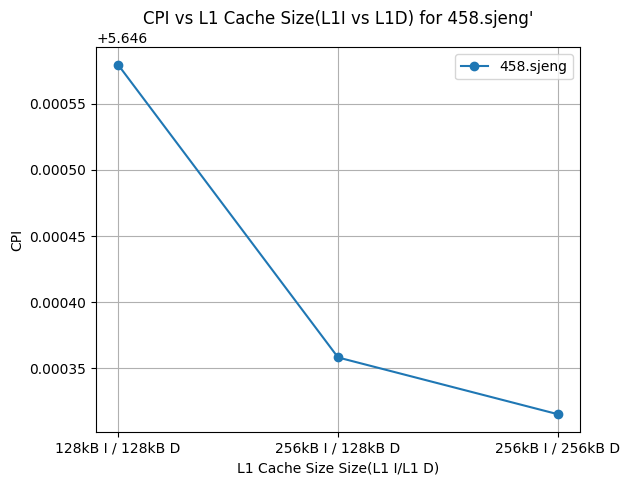

In [ ]:
cache_sizes = ['128kB I / 128kB D', '256kB I / 128kB D', '256kB I / 256kB D']


data = [
    # ['401.bzip2',2.255289467874758,2.242906422553713,2.242906422553713],
    # ['429.mcf',1.051924068121026,1.0516173523260997,1.0516173523260997],
    # ['456.hmmer',1.005578705885874,1.0036350508033214,1.0036345108046876],
    ['458.sjeng',5.646579367883487,5.646358088264088,5.646315148337945],
    # ['470.lbm', 1.8589304769358022,1.8589303569645783,1.8589303569645783]
    ]


for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1 Cache Size Size(L1 I/L1 D)")
plt.ylabel("CPI")
plt.title("CPI vs L1 Cache Size(L1I vs L1D) for 458.sjeng'")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1size_graph_458.sjeng.png")
files.download('l1size_graph_458.sjeng.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

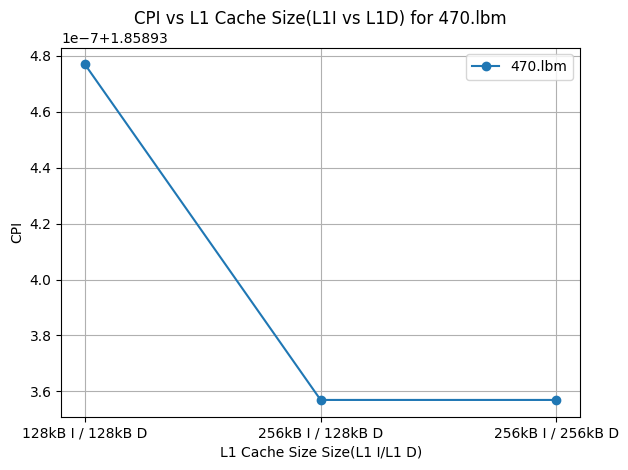

In [ ]:
cache_sizes = ['128kB I / 128kB D', '256kB I / 128kB D', '256kB I / 256kB D']


data = [
    # ['401.bzip2',2.255289467874758,2.242906422553713,2.242906422553713],
    # ['429.mcf',1.051924068121026,1.0516173523260997,1.0516173523260997],
    # ['456.hmmer',1.005578705885874,1.0036350508033214,1.0036345108046876],
    # ['458.sjeng',5.646579367883487,5.646358088264088,5.646315148337945],
     ['470.lbm', 1.8589304769358022,1.8589303569645783,1.8589303569645783]
    ]


for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cache_sizes, values, marker='o', label=benchmark)

plt.xlabel("L1 Cache Size Size(L1 I/L1 D)")
plt.ylabel("CPI")
plt.title("CPI vs L1 Cache Size(L1I vs L1D) for 470.lbm")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("l1size_graph_470.lbm.png")
files.download('l1size_graph_470.lbm.png')
plt.show()

In [67]:
benchmarks = ["401.bzip2", "429.mcf", "456.hmmer", "458.sjeng", "470.lbm"]

cpi_data = []
cost_data = []
eval_data = []
parameters = [1000,
    10000,
    100000,
    1000000,
   10000000,
    100000000,
]

for benchmark in benchmarks:
    cpi_row = [benchmark]
    cost_row = [benchmark]
    eval_row = [benchmark]

    for param in parameters:
      cpi_row.append(get_metric(results, "CPI", benchmark, max_int=param))
      cost_row.append(get_metric(results, "cost", benchmark, max_int=param))
      eval_row.append(get_metric(results, "eval", benchmark, max_int=param))

    cpi_data.append(cpi_row)
    cost_data.append(cost_row)
    eval_data.append(eval_row)

print(cpi_data)
#plot_all_metrics_for_benchmark("Max Int", parameters, cpi_data, cost_data, eval_data)

TypeError: get_metric() got an unexpected keyword argument 'max_int'

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

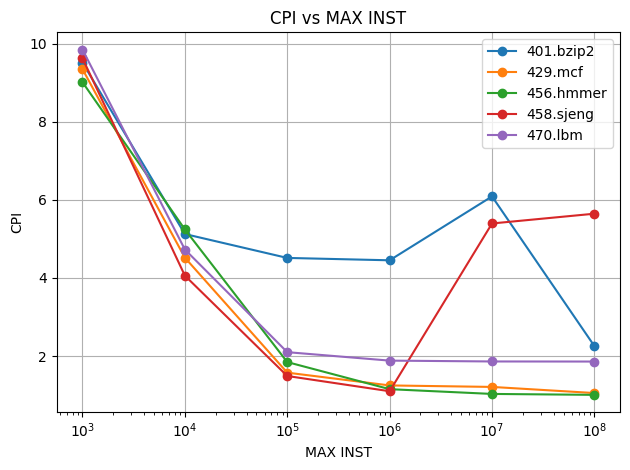

In [ ]:
max_int = [1000,
    10000,
    100000,
    1000000,
   10000000,
    100000000,
]


data = [
    ['401.bzip2',9.516898608349901,5.125917112829665,4.5137153667284124,4.452907477101169,6.089561218472485,2.255289467874758],
    ['429.mcf',9.34990059642147,4.5201516360734235,1.5744132112439522,1.2470565060839707,1.2088548478236458,1.051924068121026],
    ['456.hmmer',9.015904572564612,5.243464378367591,1.8451303991443337,1.1512642855214383,1.029331662685879,1.005578705885874],
    ['458.sjeng',9.628230616302186,4.060127846584098,1.4888813342398912,1.0984528185661773,5.396377207245585,5.646579367883487],
    ['470.lbm', 9.85089463220676,4.729459918139163,2.099525213653856,1.8827955903509184,1.8610959869903456,1.8589304769358022]]



for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(max_int, values, marker='o', label=benchmark)

plt.xscale('log')

plt.xlabel("MAX INST")
plt.ylabel("CPI")
plt.title("CPI vs MAX INST")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("max_inst_graph.png")
files.download('max_inst_graph.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

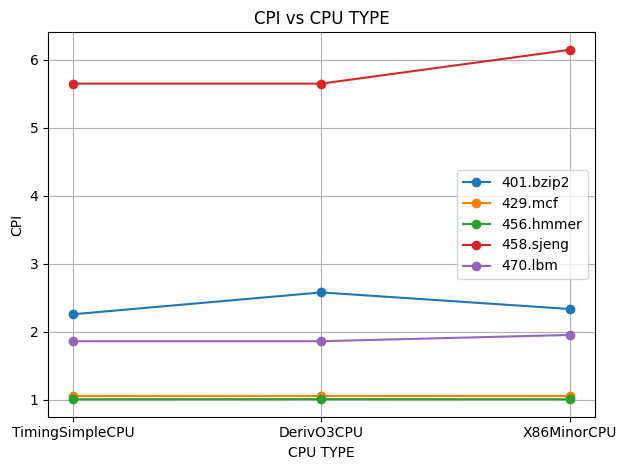

In [ ]:
cpu_type = ["TimingSimpleCPU", "DerivO3CPU", "X86MinorCPU"]


data = [
    ['401.bzip2', 2.255289467874758,2.5765694054058357,2.33271066],
    ['429.mcf', 1.051924068121026,1.0526544794734551,1.05308252],
    ['456.hmmer',1.005578705885874,1.0071022799289773,1.0061397],
    ['458.sjeng',5.646579367883487,5.64706550705869,6.14411184],
    ['470.lbm', 1.8589304769358022,1.8592115714078843,1.9510337]]


for row in data:
    benchmark = row[0]
    values = row[1:]
    plt.plot(cpu_type, values, marker='o', label=benchmark)

plt.xlabel("CPU TYPE")
plt.ylabel("CPI")
plt.title("CPI vs CPU TYPE")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("cpu_graph.png")
files.download('cpu_graph.png')
plt.show()